#### Dataset

In [1]:
# toxic-comments.csv
# https://mitu.co.in/dataset

#### Import necessary libraries

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import re

#### Load the data

In [3]:
df = pd.read_csv('datasets/toxic-comments.csv')

In [4]:
df.shape

(159571, 8)

In [5]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [6]:
df.dtypes

id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object

In [7]:
comments = df.sum(numeric_only=True)

In [8]:
comments

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [9]:
comments.sum()

35098

<BarContainer object of 6 artists>

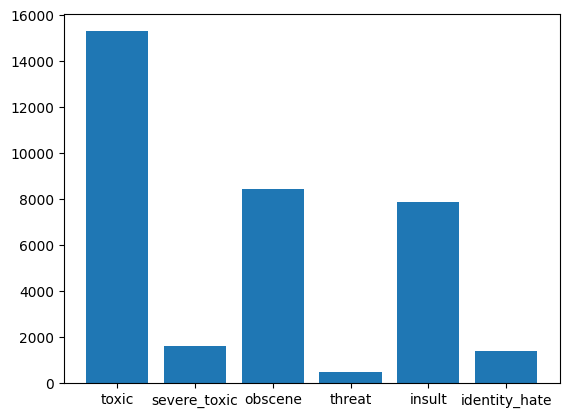

In [10]:
plt.bar(comments.index, comments)

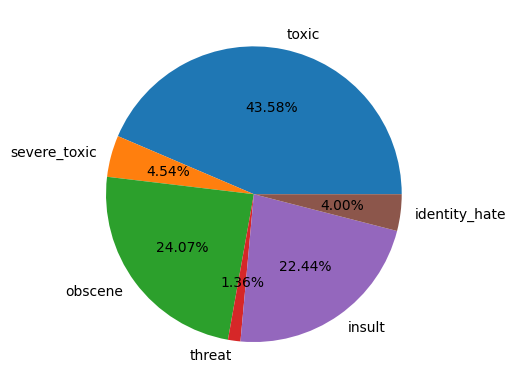

In [11]:
plt.pie(comments, labels=comments.index, autopct='%2.2f%%');

In [12]:
total = df.sum(numeric_only=True, axis=1)

In [13]:
sum(total == 0)

143346

In [14]:
newdf = pd.DataFrame({
    'neutral': [sum(total == 0)],
    'toxic': [sum(total != 0)]
})

In [15]:
newdf.T

,0
neutral,143346
toxic,16225


#### Data Cleaning

In [16]:
def clean_text(text): 
    text = text.lower()
    text = re.sub(r'[^a-z0-9]+',' ',text) 
    return text    

In [17]:
sample_text = 'Hello, how are you?'

In [18]:
clean_text(sample_text)

'hello how are you '

In [19]:
# define input variables 
comments = df['comment_text']

# define output variable
labels = df.drop(['id','comment_text'], axis = 1)

In [20]:
labels

,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0,0,0,0,0,0
1,0,0,0,0,0,0
2,0,0,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
...,...,...,...,...,...,...
159566,0,0,0,0,0,0
159567,0,0,0,0,0,0
159568,0,0,0,0,0,0
159569,0,0,0,0,0,0


In [21]:
comments_text = comments.apply(clean_text)

In [22]:
comments_text

0         explanation why the edits made under my userna...
1         d aww he matches this background colour i m se...
2         hey man i m really not trying to edit war it s...
3          more i can t make any real suggestions on imp...
4         you sir are my hero any chance you remember wh...
                                ...                        
159566     and for the second time of asking when your v...
159567    you should be ashamed of yourself that is a ho...
159568    spitzer umm theres no actual article for prost...
159569    and it looks like it was actually you who put ...
159570     and i really don t think you understand i cam...
Name: comment_text, Length: 159571, dtype: object

#### Prepare the input data

In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Embedding, LSTM, GRU 
from sklearn.model_selection import train_test_split

2026-06-04 09:35:11.908622: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-04 09:35:12.855057: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780545913.266714    4638 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780545913.378455    4638 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-04 09:35:13.999334: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [24]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(comments_text)
sequences = tokenizer.texts_to_sequences(comments_text)
padded = pad_sequences(sequences, maxlen=200, padding='post')

In [25]:
padded.shape

(159571, 200)

In [26]:
padded

array([[ 678,   77,    1, ...,    0,    0,    0],
       [ 161,   51, 2619, ...,    0,    0,    0],
       [ 407,  417,    3, ...,    0,    0,    0],
       ...,
       [  48,  732,   25, ...,    0,    0,    0],
       [   5,   10,  568, ...,    0,    0,    0],
       [   5,    3,  137, ...,    0,    0,    0]], dtype=int32)

#### Cross Validation

In [27]:
x_train, x_test, y_train, y_test = train_test_split(
    padded, labels, random_state=0, test_size=0.2)

In [28]:
x_train.shape, y_train.shape

((127656, 200), (127656, 6))

In [29]:
x_test.shape, y_test.shape

((31915, 200), (31915, 6))

#### Build the model

In [30]:
model = Sequential()

model.add(Embedding(5000, 100, input_length=200))
model.add(GRU(128))
model.add(Dense(6,activation='sigmoid'))

/home/mitu/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-06-04 09:36:49.925967: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [31]:
model.compile(loss='binary_crossentropy', optimizer='adam', 
              metrics=['accuracy'])

In [32]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.fit(x_train, y_train, epochs=3, validation_data = (x_test, y_test))

Epoch 1/3
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 1525s 379ms/step - accuracy: 0.9853 - loss: 0.0983 - val_accuracy: 0.9908 - val_loss: 0.0547
Epoch 2/3
1020/3990 ━━━━━━━━━━━━━━━━━━━━ 8:11 166ms/step - accuracy: 0.9915 - loss: 0.0449

KeyboardInterrupt: 